# M2A7 - Introdução a Redes Neurais

> **Resumo:** Das máquinas clássicas pro Deep Learning! Aqui entendemos o perceptron, funções de ativação, e o MLP (Multilayer Perceptron). Implementamos um perceptron do ZERO com NumPy!

> 📝 **Dado histórico:** O Perceptron surgiu em 1958. Redes neurais são uma ideia velha com implementação moderna!

**Estrutura do notebook:**

- Conceitos (neurônio artificial, perceptron, ativação, MLP)
- Prática: perceptron do zero com NumPy
- MLP com scikit-learn
- ✅ Atividades Complementares

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Funções de Ativação

A função de ativação decide se um neurônio "dispara" ou não. Duas das mais importantes:

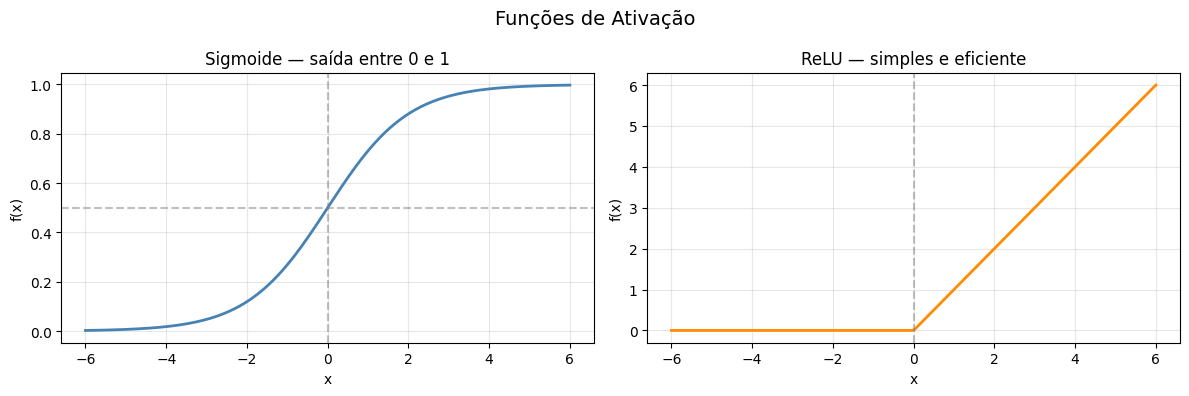

In [2]:
x = np.linspace(-6, 6, 200)

# Sigmoide: f(x) = 1 / (1 + e^(-x))
sigmoid = 1 / (1 + np.exp(-x))

# ReLU: f(x) = max(0, x)
relu = np.maximum(0, x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, sigmoid, linewidth=2, color='steelblue')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title("Sigmoide — saída entre 0 e 1")
axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)")
axes[0].grid(alpha=0.3)

axes[1].plot(x, relu, linewidth=2, color='darkorange')
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title("ReLU — simples e eficiente")
axes[1].set_xlabel("x"); axes[1].set_ylabel("f(x)")
axes[1].grid(alpha=0.3)

plt.suptitle("Funções de Ativação", fontsize=14)
plt.tight_layout()
plt.show()

> 📝 **Sigmoide:** usada historicamente, saturava gradientes. **ReLU:** mais simples, resolveu o vanishing gradient, domina o Deep Learning moderno.

## Perceptron do Zero com NumPy

Um perceptron é literalmente: `saída = ativação(pesos · entradas + bias)`

In [3]:
class Perceptron:
    """Perceptron simples com aprendizado."""
    def __init__(self, n_features, lr=0.01):
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0
        self.lr = lr

    def predict(self, X):
        linear = X @ self.weights + self.bias
        return (linear >= 0).astype(int)

    def fit(self, X, y, epochs=100):
        losses = []
        for epoch in range(epochs):
            errors = 0
            for xi, yi in zip(X, y):
                pred = int((xi @ self.weights + self.bias) >= 0)
                error = yi - pred
                self.weights += self.lr * error * xi
                self.bias += self.lr * error
                errors += abs(error)
            losses.append(errors)
        return losses

Histórico de erros por época no Perceptron (amostragem a cada 5 épocas):
  - Época 00: 6 erros acumulados
  - Época 05: 0 erros acumulados
  - Época 10: 0 erros acumulados
  - Época 15: 0 erros acumulados
  - Época 20: 0 erros acumulados
  - Época 25: 0 erros acumulados
  - Época 30: 0 erros acumulados
  - Época 35: 0 erros acumulados
  - Época 40: 0 erros acumulados
  - Época 45: 0 erros acumulados


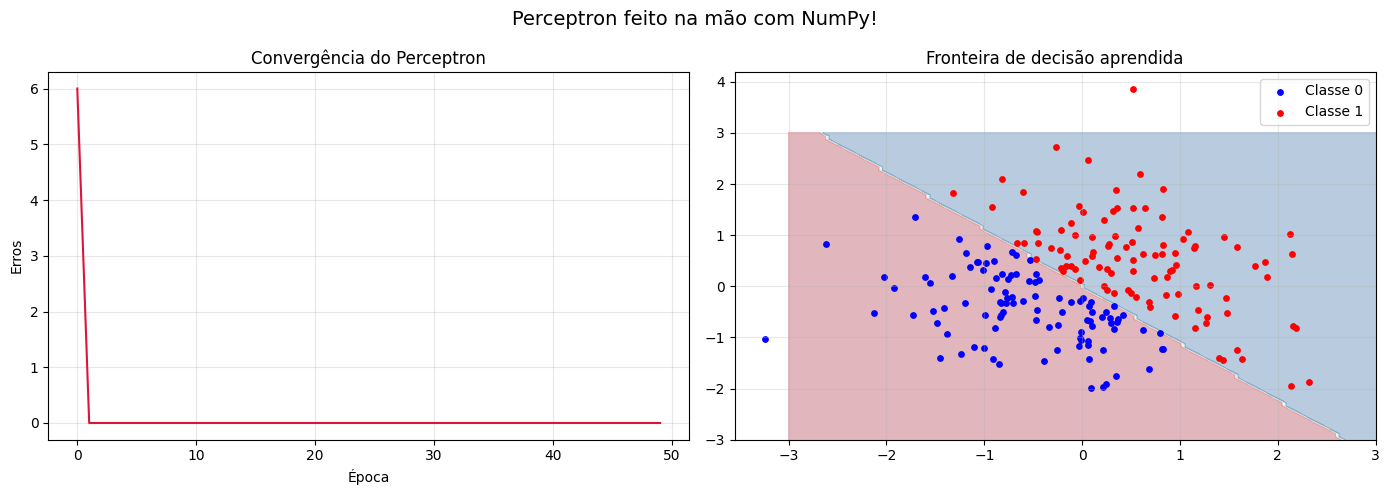

In [4]:
# Problema: classificar pontos acima/abaixo de uma linha
np.random.seed(42)
X = np.random.randn(200, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)  # Classe 1 se x+y > 0

# Treinar
p = Perceptron(n_features=2, lr=0.1)
losses = p.fit(X, y, epochs=50)

print("Histórico de erros por época no Perceptron (amostragem a cada 5 épocas):")
for ep, err in enumerate(losses[::5]):
    print(f"  - Época {ep*5:02d}: {err} erros acumulados")


# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de erros
axes[0].plot(losses, color='crimson')
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Erros")
axes[0].set_title("Convergência do Perceptron")
axes[0].grid(alpha=0.3)

# Fronteira de decisão
xx, yy = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
Z = p.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
axes[1].scatter(X[y==0, 0], X[y==0, 1], c='blue', s=15, label='Classe 0')
axes[1].scatter(X[y==1, 0], X[y==1, 1], c='red', s=15, label='Classe 1')
axes[1].set_title("Fronteira de decisão aprendida")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Perceptron feito na mão com NumPy!", fontsize=14)
plt.tight_layout()
plt.show()

## MLP com scikit-learn

Agora vamos usar um MLP real (múltiplas camadas) pra classificar dígitos:

MLP (128, 64): 97.2%


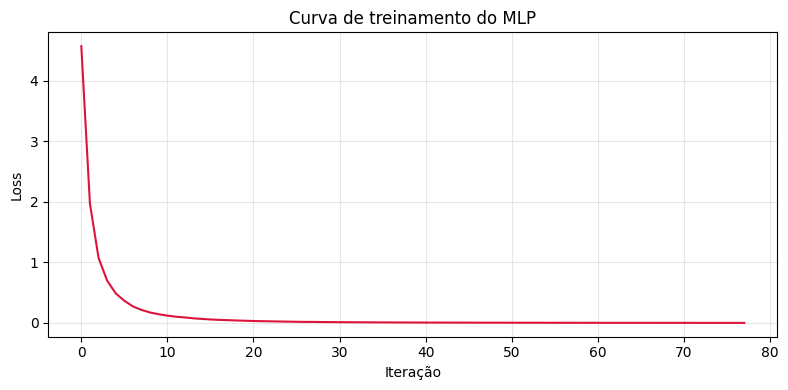

Número total de iterações do MLP: 78
Loss final obtido pelo MLP: 0.001844


In [5]:
from sklearn.neural_network import MLPClassifier
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

digits = datasets.load_digits()
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42
)

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # 2 camadas escondidas
    activation='relu',
    max_iter=200,
    random_state=42
)
mlp.fit(X_train, y_train)

acc = accuracy_score(y_test, mlp.predict(X_test))
print(f"MLP (128, 64): {acc*100:.1f}%")

# Curva de loss
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, color='crimson')
plt.xlabel("Iteração"); plt.ylabel("Loss")
plt.title("Curva de treinamento do MLP")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Número total de iterações do MLP: {mlp.n_iter_}")
print(f"Loss final obtido pelo MLP: {mlp.loss_:.6f}")

## ✅ Atividades Complementares

### Comparar MLP com modelos clássicos

KNN (K=5)                : 98.6%
SVM (RBF)                : 98.6%
MLP (128, 64)            : 97.2%
MLP (256, 128, 64)       : 97.8%


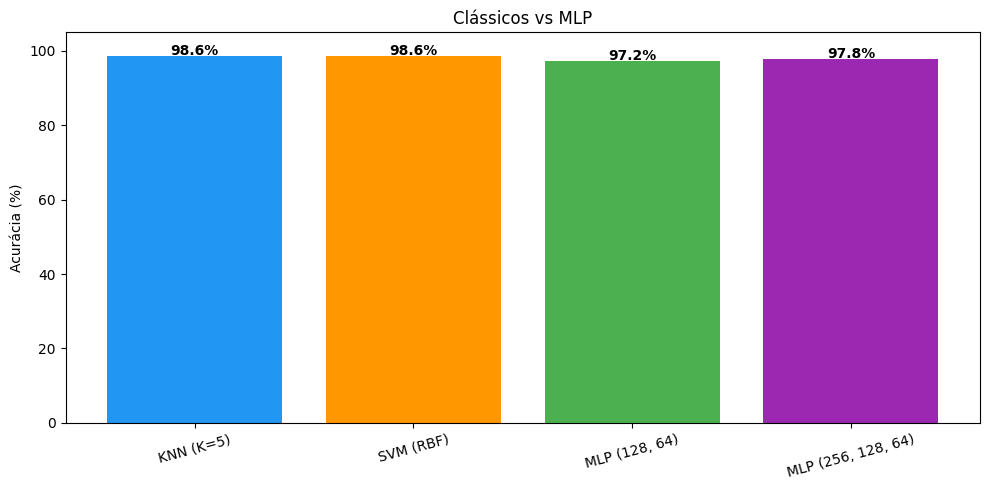

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models = {
    'KNN (K=5)': KNeighborsClassifier(5),
    'SVM (RBF)': SVC(kernel='rbf'),
    'MLP (128, 64)': MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=200, random_state=42),
    'MLP (256, 128, 64)': MLPClassifier(hidden_layer_sizes=(256, 128, 64), max_iter=200, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = acc
    print(f"{name:25s}: {acc*100:.1f}%")

plt.figure(figsize=(10, 5))
bars = plt.bar(results.keys(), [v*100 for v in results.values()],
               color=['#2196F3', '#FF9800', '#4CAF50', '#9C27B0'])
for bar, acc in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc*100:.1f}%', ha='center', fontweight='bold')
plt.ylabel("Acurácia (%)")
plt.title("Clássicos vs MLP")
plt.ylim(0, 105)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()